## GENERACIÓN DE TEXTO CON LSTM - IMPLEMENTACIÓN CON TENSORFLOW

https://github.com/olgazju/project_taylor_swift_lyrics_generation

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import Callback, EarlyStopping

In [11]:
df = pd.read_parquet("cleaned.parquet")
df

,lyric_clean
0,he said the way my blue eyes shined
1,put those georgia stars to shame that night
2,i said that is a lie
3,just a boy in a chevy truck
4,that had a tendency of gettin' stuck
...,...
5310,even when i lose my mind
5311,i need to say
5312,tell me that it is not my fault
5313,tell me that i am all you want


## Uso de LSTM para la Generación de Letras
En este proyecto, se usan redes LSTM (Memoria a Largo y Corto Plazo) para generar letras en el estilo de Taylor Swift.

### ¿Qué es un LSTM?
Las LSTM son un tipo especial de red neuronal recurrente que se destacan en el aprendizaje de secuencias, como las oraciones en una canción. Lo que hacen las LSTM con los datos es que recuerdan no solo el pasado inmediato, sino también información de mucho tiempo atrás.

### Cómo Preparamos los Datos de Entrenamiento y las Etiquetas
**1. Tokenización:** Primero, convertimos las letras en un formato que nuestro modelo LSTM pueda entender. Hacemos esto descomponiendo las letras en palabras individuales y luego convirtiendo cada palabra en un número único.

**2. Creación de Secuencias de Entrada:** Luego, creamos secuencias de estos números. Cada secuencia es una parte de una línea de letra y, con cada paso, agregamos una palabra a la secuencia. De esta manera, el modelo aprende a predecir la siguiente palabra en una secuencia.

**3. Relleno:** Dado que no todas las secuencias tienen la misma longitud, las hacemos uniformes agregando ceros a las secuencias más cortas, un proceso conocido como padding.

**4. División de los Datos:** Luego, las secuencias se dividen en dos partes: predictores y la etiqueta. Los predictores son las secuencias de números que ingresamos en el modelo, y la etiqueta es el siguiente número que el modelo necesita predecir.

**5. Codificación One-Hot:** Finalmente, convertimos las etiquetas en un formato donde todas las posibilidades se representan como ceros, excepto la etiqueta real, que se representa como un uno.

**6. División en Entrenamiento y Prueba:** Por último, dividimos nuestro conjunto de datos en un conjunto de entrenamiento y un conjunto de validación. El conjunto de entrenamiento se usa para entrenar el modelo, mientras que el conjunto de validación se usa para probar su rendimiento y precisión.

In [12]:
combined_lyrics = ' '.join(df['lyric_clean'])
tokenizer = Tokenizer()
tokenizer.fit_on_texts([combined_lyrics])
total_words = len(tokenizer.word_index) + 1
input_sequences = []
for line in df['lyric_clean']:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(x) for x in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
predictors, label = input_sequences[:,:-1], input_sequences[:,-1]
label = to_categorical(label, num_classes=total_words)

# Splitting Data
X_train, X_val, y_train, y_val = train_test_split(predictors, label, test_size=0.2, random_state=42)

In [13]:
X_train[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        2, 25,  5,  6, 19], dtype=int32)

In [14]:
# Perplexity Calculation
class Perplexity(Callback):
    def on_epoch_end(self, epoch, logs={}):
        cross_entropy = logs.get('loss')
        perplexity = np.exp(cross_entropy)
        print(f' - perplexity: {perplexity}')

def viz_metrics(history):
    # Visualizing Training and Validation Metrics
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

def train(model):
  #earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=1, mode='auto', restore_best_weights=True)
  #history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[earlystop, Perplexity()])
  history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=Perplexity())
  return history

def generate(model, seed_text):
  next_words = 100  # Number of words you want to generate

  for _ in range(next_words):
      # Tokenize the current seed text
      token_list = tokenizer.texts_to_sequences([seed_text])[0]

      # Pad the sequence
      token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

      # Predict the next word (as probabilities)
      probabilities = model.predict(token_list, verbose=0)

      # Get the index of the most likely next word
      predicted = np.argmax(probabilities, axis=-1)[0]

      # Convert the predicted token to a word
      output_word = ""
      for word, index in tokenizer.word_index.items():
          if index == predicted:
              output_word = word
              break

      # Update the seed text
      seed_text += " " + output_word

  return seed_text


def sample_with_temperature(probabilities, temperature=1.0):
    # Adjust the probabilities with temperature
    probabilities = np.asarray(probabilities).astype('float64')
    probabilities = np.log(probabilities + 1e-10) / temperature  # Adding a small constant to avoid division by zero
    exp_probs = np.exp(probabilities)
    probabilities = exp_probs / np.sum(exp_probs)

    # Sample the next word based on the adjusted probabilities
    choices = range(len(probabilities))
    next_word = np.random.choice(choices, p=probabilities)

    return next_word

def generate_with_temperature(model, seed_text, temperature=1.0):

    next_words = 100
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

        probabilities = model.predict(token_list, verbose=0)[0]

        # Use temperature to adjust the probabilities and sample the next word
        predicted = sample_with_temperature(probabilities, temperature=temperature)

        # Convert the predicted token to a word and update the seed text
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word

    return seed_text


## Arquitectura del Modelo

### Capa de Entrada (Capa de Embedding):

- **Embedding**: La primera capa es una capa de Embedding, que se usa para convertir nuestros datos de entrada en vectores densos de tamaño fijo. Aquí, `total_words` es el tamaño del vocabulario, y 100 es la dimensionalidad de los vectores de embedding. La `input_length` se establece en `max_sequence_len - 1`, que es la longitud de las secuencias de entrada.

### Capa LSTM:

- **LSTM**: Después de la capa de Embedding, tenemos una capa LSTM con 150 unidades. Esta capa procesará la secuencia de embeddings de palabras generada por la capa anterior.

### Dropout para Regularización:

- **Dropout(0.1)**: Después de la primera capa LSTM, colocamos una capa Dropout con una tasa de deserción del 10% (0.1). Dropout es una técnica de regularización donde se ignoran neuronas seleccionadas al azar durante el entrenamiento, lo que ayuda a prevenir el sobreajuste.

### Capa de Salida (Capa Dense):

- **Dense**: La capa final es una capa Dense con una función de activación softmax. El tamaño de esta capa es igual a `total_words`, que representa el número total de palabras únicas en el vocabulario. La función de activación softmax producirá una distribución de probabilidad sobre el vocabulario para la próxima palabra en la secuencia.

La función de pérdida utilizada es `categorical_crossentropy`, que es adecuada para problemas de clasificación multiclase. Usamos el optimizador `adam`, que es un algoritmo para la optimización basada en gradientes de primer orden de funciones objetivo estocásticas. La métrica que nos interesa monitorear es `accuracy`.

## Early Stopping

- **EarlyStopping**: EarlyStopping es una callback que detiene el proceso de entrenamiento cuando una métrica monitoreada ha dejado de mejorar. Estamos monitoreando la pérdida de validación (`val_loss`), y si la pérdida no disminuye (`min_delta=0`) durante tres épocas (`patience=3`), el entrenamiento se detendrá. La configuración `verbose=1` nos permite ver la salida de los eventos de parada temprana. El `mode='auto'` determinará automáticamente la dirección de mejora y `restore_best_weights=True` asegura que los pesos del modelo volverán a aquellos que produjeron la menor pérdida de validación. Si el `val_loss` comienza a aumentar a medida que avanza el entrenamiento, puede ser un indicador de sobreajuste.

## Entrenamiento del Modelo

- El modelo se entrenará durante un máximo de 100 épocas en los datos de entrenamiento `X_train` y `y_train`.
- Durante el entrenamiento, el rendimiento del modelo también se valida utilizando un conjunto de validación separado.
- `Perplexity()` es una callback personalizada (no proporcionada en las callbacks estándar de Keras) que calcula la métrica de perplexidad después de cada época, una métrica común de evaluación en la modelación de lenguaje. Una menor puntuación de perplexidad indica un mejor rendimiento predictivo, ya que significa que el modelo está más seguro de sus predicciones.


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 22, 100)           357300    
                                                                 
 lstm_1 (LSTM)               (None, 150)               150600    
                                                                 
 dropout_1 (Dropout)         (None, 150)               0         
                                                                 
 dense_1 (Dense)             (None, 3573)              539523    
                                                                 
Total params: 1047423 (4.00 MB)
Trainable params: 1047423 (4.00 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
882/882 [==============================] - 15s 14ms/step - loss: 6.0913 - accuracy: 0.0472 - val_loss: 5.8653 - val_accuracy: 0.0668
Epoc

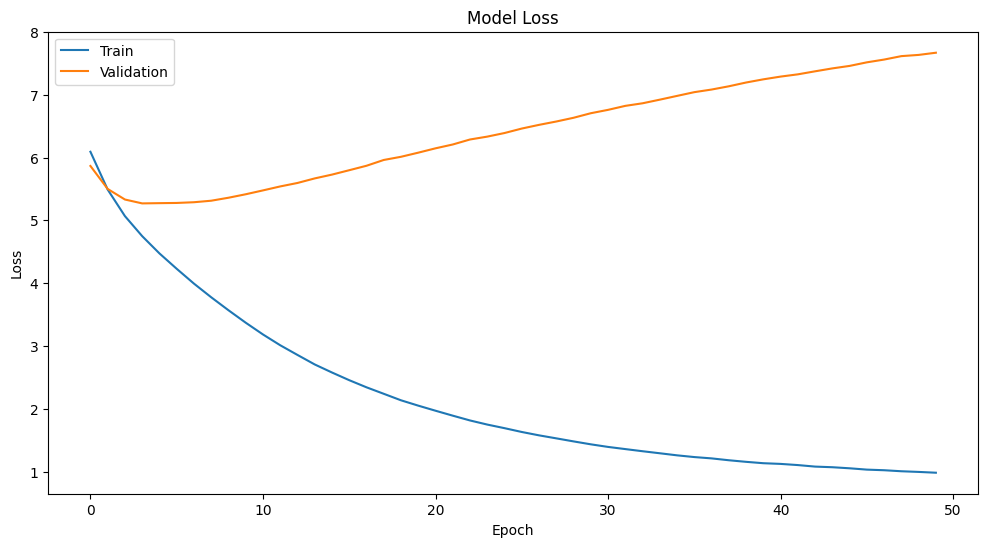

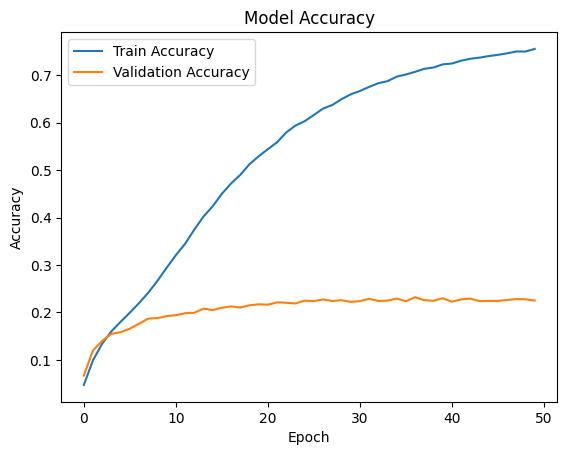

In [15]:
# Building the Model
baseline_model = Sequential()
baseline_model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
baseline_model.add(LSTM(150))
baseline_model.add(Dropout(0.1))
baseline_model.add(Dense(total_words, activation='softmax'))
baseline_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

baseline_model.summary()

history = train(baseline_model)
viz_metrics(history)

Hemos obtenido:

- accuracy: 0.7553
- val_accuracy: 0.2
- perplexity: 2.681

Para los modelos generativos, como los utilizados en la generación de texto, el objetivo suele ser producir texto que sea coherente y contextualmente relevante, en lugar de maximizar la precisión de la predicción de la siguiente palabra. Un modelo podría tener una menor precisión pero aún así generar texto de alta calidad y diverso. Esto se debe a que puede aprender a producir texto que siga el estilo y la estructura del lenguaje, aunque no siempre adivine la palabra exacta que aparece en el conjunto de entrenamiento.


### Generación de Texto

1. **Comenzando con la Semilla**: Comenzamos con el texto semilla y lo preparamos para la predicción. Esto implica tokenizar el texto (convertir palabras en valores numéricos) y rellenarlo para asegurarnos de que se ajuste a la forma de entrada esperada por el modelo.

2. **Generación Palabra por Palabra**:
   - El modelo predice la próxima palabra basándose en el texto semilla actual, una palabra a la vez.
   - Genera una distribución de probabilidad sobre todo el vocabulario para la siguiente palabra.
   - Se elige la palabra correspondiente a la probabilidad más alta (la palabra más probable) y se agrega al texto semilla.

3. **Actualización del Texto Semilla**:
   - Después de cada predicción, se actualiza el texto semilla para incluir la nueva palabra.
   - Este texto semilla actualizado se vuelve a alimentar al modelo para la siguiente ronda de predicción.

4. **Repetición del Proceso**:
   - Este bucle continúa durante un número definido de iteraciones (por ejemplo, 100 palabras en nuestro caso).


In [19]:
generate(baseline_model, 'The')

'The first time you ever saw me cry dreams are you just met me in a crowded room out and a girl dress yeah yeah just like bad time is cold hard not many golden only see you see us when i was dead i do not know how to be whole life girl i do not wanna lose you around at midnight leave me the time door over never smile is me like you are like to believe in my man you are my best friends i dreamed of it all too well yeah yeah yeah yeah yeah you are'